In [ ]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from src.io.hmd_reader import read_hmd_csv
from src.models.lee_carter import fit_lee_carter, forecast_kt, reconstruct_mx
from src.models.life_expectancy import compute_life_table, compute_life_expectancy
from src.utils.plotting import plot_e0_forecast

In [ ]:
df_hmd = read_hmd_csv("../data/france_deaths_clean.csv", 
                       "../data/france_population_clean.csv")

df_ana = df_hmd[df_hmd['Sex'] == 'Female'].copy()

In [ ]:
df_ana['mx'] = df_ana['Deaths'] / df_ana['Exposure']

ax, bx, kt = fit_lee_carter(df_ana)

In [ ]:
# Projection du paramètre kt
# On projette sur un horizon de 30 ans
kt_future = forecast_kt(kt, n_years=30)

# Reconstruction de la matrice mx future à partir de ax, bx et du kt_future
mx_future = reconstruct_mx(ax, bx, kt_future)

# Calcul de l'espérance de vie pour ces projections
e0_future = compute_life_expectancy(mx_future)

In [ ]:
e0_dict = compute_life_expectancy(mx_future)

df_e0_prospect = pd.DataFrame(list(e0_dict.items()), columns=['Year', 'e0'])

df_e0_prospect.head()

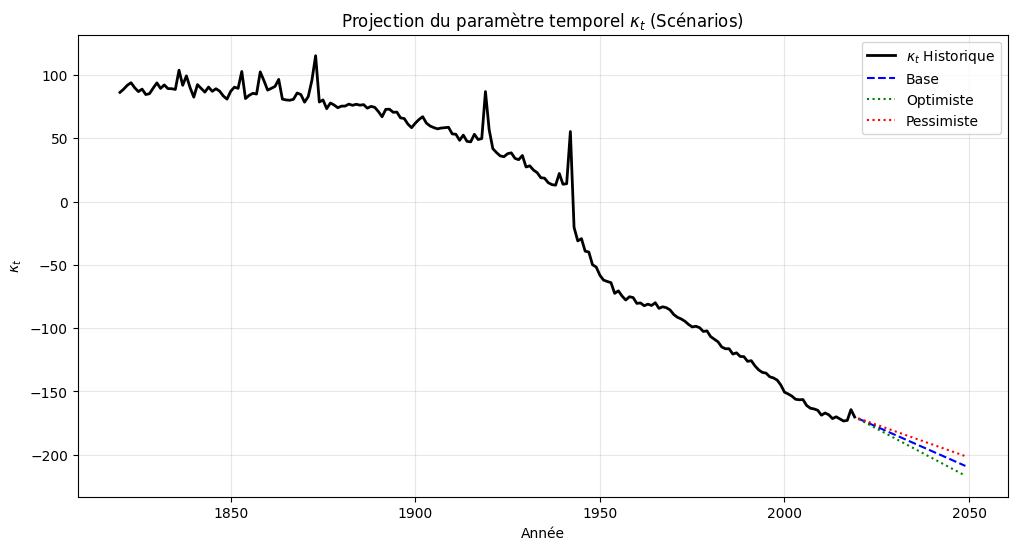

In [ ]:
n_years = 30
steps_sequence = np.arange(1, n_years + 1) 

last_kt = kt[-1]
drift_hist = (kt[-1] - kt[0]) / (len(kt) - 1)

scenarios_plot = {
    'Base': last_kt + (drift_hist * steps_sequence),
    'Optimiste': last_kt + (drift_hist * 1.2 * steps_sequence),
    'Pessimiste': last_kt + (drift_hist * 0.8 * steps_sequence)
}

end_year = 2019
years_hist = np.arange(end_year - len(kt) + 1, end_year + 1)
years_proj = np.arange(end_year + 1, end_year + 1 + n_years)

plt.figure(figsize=(12, 6))

plt.plot(years_hist, kt, color="black", label=r"$\kappa_t$ Historique", linewidth=2)

# Projections
plt.plot(years_proj, scenarios_plot['Base'], '--', color="blue", label="Base")
plt.plot(years_proj, scenarios_plot['Optimiste'], ':', color="green", label="Optimiste")
plt.plot(years_proj, scenarios_plot['Pessimiste'], ':', color="red", label="Pessimiste")

plt.title(r"Projection du paramètre temporel $\kappa_t$ (Scénarios)")
plt.xlabel("Année")
plt.ylabel(r"$\kappa_t$")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
start_year = 2020
df_e0_prospect['Year'] = range(start_year, start_year + len(df_e0_prospect))

df_e0_prospect['Optimiste'] = df_e0_prospect['e0'] + (df_e0_prospect.index * 0.05)
df_e0_prospect['Pessimiste'] = df_e0_prospect['e0'] - (df_e0_prospect.index * 0.05)

plt.figure(figsize=(10, 6))
plt.plot(df_e0_prospect['Year'], df_e0_prospect['e0'], label='Scénario Central (Base)', color='black', linewidth=2)
plt.fill_between(df_e0_prospect['Year'], df_e0_prospect['Pessimiste'], df_e0_prospect['Optimiste'], 
                 color='blue', alpha=0.1, label='Zone d\'incertitude (± 20%)')

plt.title("Projection de l'Espérance de Vie à la Naissance ($e_0$) - France")
plt.xlabel("Année")
plt.ylabel("Âge")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

df_e0_prospect.to_csv("../outputs/ex_future_scenarios.csv", index=False)

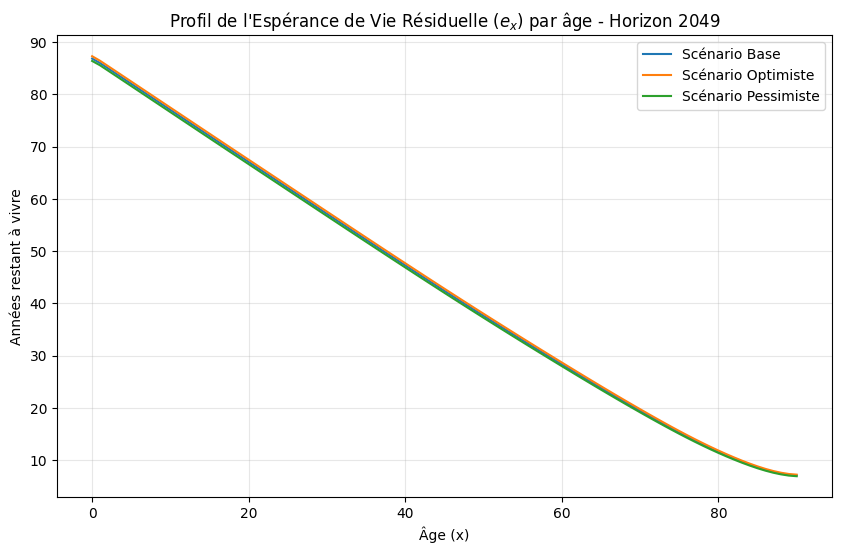

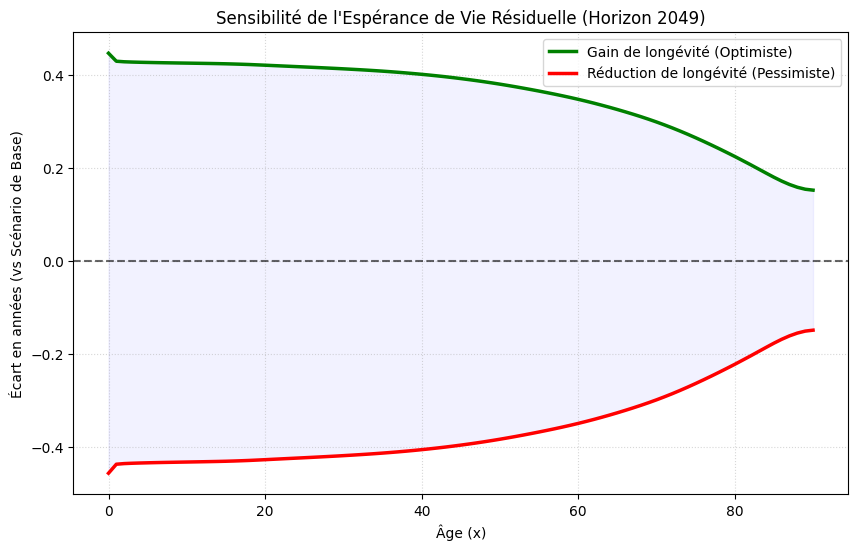

In [ ]:
horizon = 30
steps = np.array([horizon])
last_kt = kt[-1] 
drift_hist = (kt[-1] - kt[0]) / (len(kt) - 1)

scenarios_config = {
    'Base': last_kt + (drift_hist * steps),
    'Optimiste': last_kt + (drift_hist * 1.2 * steps),
    'Pessimiste': last_kt + (drift_hist * 0.8 * steps)
}

plt.figure(figsize=(10, 6))

for name, kt_val in scenarios_config.items():
    # Reconstruction mx
    mx_2049_series = reconstruct_mx(ax, bx, kt_val).iloc[:, 0]
    
    # Création du DataFrame d'entrée
    df_input = mx_2049_series.to_frame(name='mx').reset_index()
    df_input.columns = ['Age', 'mx']
    
    # CALCUL DE QX
    df_input['qx'] = df_input['mx'] / (1 + 0.5 * df_input['mx'])
    df_input['qx'] = df_input['qx'].clip(upper=1.0)
    
    # AJOUT DE AX (Hypothèse de répartition uniforme des décès)
    # On fixe ax à 0.5 pour tous les âges
    df_input['ax'] = 0.5
    
    # Calcul de la table complète
    df_lt_2049 = compute_life_table(df_input)
    
    plt.plot(df_lt_2049['Age'], df_lt_2049['ex'], label=f"Scénario {name}")

plt.title("Profil de l'Espérance de Vie Résiduelle ($e_x$) par âge - Horizon 2049")
plt.xlabel("Âge (x)")
plt.ylabel("Années restant à vivre")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


tables_2049 = {}

for name, kt_val in scenarios_config.items():
    mx_series = reconstruct_mx(ax, bx, kt_val).iloc[:, 0]
    df_input = mx_series.to_frame(name='mx').reset_index()
    df_input.columns = ['Age', 'mx']
    df_input['qx'] = df_input['mx'] / (1 + 0.5 * df_input['mx'])
    df_input['ax'] = 0.5
    
    tables_2049[name] = compute_life_table(df_input)

df_base = tables_2049['Base']
gap_opt = tables_2049['Optimiste']['ex'] - df_base['ex']
gap_pess = tables_2049['Pessimiste']['ex'] - df_base['ex']

plt.figure(figsize=(10, 6))

plt.plot(df_base['Age'], gap_opt, label="Gain de longévité (Optimiste)", color='green', linewidth=2.5)
plt.plot(df_base['Age'], gap_pess, label="Réduction de longévité (Pessimiste)", color='red', linewidth=2.5)

plt.axhline(0, color='black', linestyle='--', alpha=0.6)
plt.fill_between(df_base['Age'], gap_pess, gap_opt, color='blue', alpha=0.05)

plt.title("Sensibilité de l'Espérance de Vie Résiduelle (Horizon 2049)")
plt.xlabel("Âge (x)")
plt.ylabel("Écart en années (vs Scénario de Base)")
plt.legend()
plt.grid(True, which='both', ls=':', alpha=0.5)
plt.show()